# FinAI — FX Volatility Surface Analysis (CNY/CNH)

The workflow decomposes implied volatility surfaces into latent factors, models their conditional mean, and forecasts conditional variance using econometric volatility models.


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

pd.set_option("display.max_rows", 200)     
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_PATH = Path("FINAL_Data.csv")

IS_END    = pd.Timestamp("2019-12-31")
OOS_START = pd.Timestamp("2020-01-01")
TENORS    = ["1M", "3M", "6M", "1Y"]
SMILES    = ["ATM", "25DRR", "25DBF", "10DRR", "10DBF"]

## 1. Data Ingestion & Panel Construction

### 1.1 Load raw data
- Load `FINAL_Data.csv`
- Robust mixed-format date parsing (string + Excel serials)
- Enforce:
  - DatetimeIndex
  - Monotonic increasing
  - Unique dates

### 1.2 Column taxonomy
We explicitly separate the panel into:
- **Surface nodes**: IV smiles by market × tenor × smile
- **Spot & fixing levels**
- **Macro / policy drivers**
- **Returns (RET_)**
- **Changes (CHG_)**

This separation is critical for:
- PCA isolation
- HAR-X macro conditioning
- Avoiding sparse CNH surface leakage

### 1.3 Frozen daily panel
- Drop days with no surface information
- Coerce all values to numeric
- Forward-fill levels only (no backfill)
- Save immutable snapshot as `panel0`


In [4]:
import pandas as pd
def parse_mixed_date(x):
    dt = pd.to_datetime(x, errors="coerce")
    if not pd.isna(dt):
        return dt
    try:
        xf = float(x)
        if 30000 < xf < 50000: 
            return pd.to_datetime("1899-12-30") + pd.to_timedelta(xf, unit="D")
    except Exception:
        pass
    return pd.NaT

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

df_raw["Date_parsed"] = df_raw["Date"].apply(parse_mixed_date)
bad = int(df_raw["Date_parsed"].isna().sum())
print("Unparsable rows:", bad)

df = (
    df_raw.dropna(subset=["Date_parsed"])
          .drop(columns=["Date"])
          .rename(columns={"Date_parsed": "Date"})
          .sort_values("Date")
          .set_index("Date")
)

assert isinstance(df.index, pd.DatetimeIndex)
assert df.index.is_monotonic_increasing
assert df.index.is_unique

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "->", df.index.max().date())

/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_2669/1794200627.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt = pd.to_datetime(x, errors="coerce")


Unparsable rows: 0
Shape: (5929, 145)
Date range: 2004-01-03 -> 2025-12-23


In [5]:
# Surface nodes (exact naming assumed like CNY_1M_ATM)
SURFACE_COLS = [c for c in df.columns if re.match(r"^(CNY|CNH)_(1M|3M|6M|1Y)_(ATM|25DRR|25DBF|10DRR|10DBF)$", str(c))]

SPOT_COLS = [c for c in [
    "CNY_SPOT","CNH_SPOT",
    "CNY_CNY_PBOC_FIXING","CNH_CNH_PBOC_FIXING",
    "FEAT_CNY_Spot_Fix_Dev"
] if c in df.columns]

DRIVER_LEVEL_COLS = [c for c in df.columns if str(c).startswith(("DRV_","POL_","CN_","US_","OTH_"))]
RETURN_COLS       = [c for c in df.columns if str(c).startswith("RET_")]
CHANGE_COLS       = [c for c in df.columns if str(c).startswith("CHG_")]

print("Surface cols:", len(SURFACE_COLS))
print("Spot cols:", len(SPOT_COLS))
print("Driver levels:", len(DRIVER_LEVEL_COLS))
print("Returns:", len(RETURN_COLS))
print("Changes:", len(CHANGE_COLS))

Surface cols: 40
Spot cols: 5
Driver levels: 39
Returns: 10
Changes: 51


In [6]:
panel = df[SURFACE_COLS + SPOT_COLS + DRIVER_LEVEL_COLS + RETURN_COLS + CHANGE_COLS].copy()

# drop days with no surface information - i rmb there wasnt any
panel = panel.dropna(subset=SURFACE_COLS, how="all")

# coerce to numeric and sort
panel = panel.apply(pd.to_numeric, errors="coerce").sort_index()

panel0 = panel.copy()
print("Frozen panel0 shape:", panel0.shape)
print("Date range:", panel0.index.min().date(), "->", panel0.index.max().date())

surface_any = panel0[SURFACE_COLS].notna().any(axis=1).mean()
print("Share of days with at least one surface node:", float(surface_any))

year_counts = panel0.groupby(panel0.index.year).size().to_frame("n")
display(year_counts)

Frozen panel0 shape: (5929, 145)
Date range: 2004-01-03 -> 2025-12-23
Share of days with at least one surface node: 1.0


,n
Date,
2004,264
2005,263
2006,267
2007,270
2008,271
2009,270
2010,273
2011,268
2012,269


## 2. Surface Block Definition (CNY / CNH)

We construct **economically coherent PCA blocks**:

### 2.1 Smile segmentation
For each market:
- ATM (level)
- 25Δ Risk Reversal (skew)
- 25Δ Butterfly (curvature)
- Optional: 10Δ RR / BF (tails)

### 2.2 CNH availability handling
- CNH surfaces start later than CNY
- Detect first valid CNH date
- Fit CNH PCA 
- Prevents sparse-era artefacts


In [7]:
def surface_cols_for(df, mkt, tenor, smile):
    pat = re.compile(rf"^{mkt}_{tenor}_{smile}$")
    return [c for c in df.columns if pat.match(str(c))]

def surface_block_cols(df, mkt, smile):
    cols = []
    for t in TENORS:
        cols += surface_cols_for(df, mkt, t, smile)
    return cols

def first_valid_date(df, cols):
    if not cols:
        return None
    s = df[cols].notna().any(axis=1)
    return s.index[s.values][0] if s.any() else None

# blocks (CNY)
ATM_CNY  = surface_block_cols(panel0, "CNY", "ATM")
RR25_CNY = surface_block_cols(panel0, "CNY", "25DRR")
BF25_CNY = surface_block_cols(panel0, "CNY", "25DBF")
RR10_CNY = surface_block_cols(panel0, "CNY", "10DRR")
BF10_CNY = surface_block_cols(panel0, "CNY", "10DBF")

# blocks (CNH)
ATM_CNH  = surface_block_cols(panel0, "CNH", "ATM")
RR25_CNH = surface_block_cols(panel0, "CNH", "25DRR")
BF25_CNH = surface_block_cols(panel0, "CNH", "25DBF")
RR10_CNH = surface_block_cols(panel0, "CNH", "10DRR")
BF10_CNH = surface_block_cols(panel0, "CNH", "10DBF")

cnh_all = ATM_CNH + RR25_CNH + BF25_CNH + RR10_CNH + BF10_CNH
CNH_START = first_valid_date(panel0, cnh_all)
print("CNH_START:", None if CNH_START is None else CNH_START.date())

CNH_START: 2011-01-03


## 3. PCA Factor Extraction (Leakage-Safe)

### 3.1 PCA input construction
- Levels forward-filled
- Transformations:
  - ATM → log-differences
  - RR / BF → level differences
- Median imputation **stored from IS only**

### 3.2 PCA fitting
- Standardise inputs (IS only)
- PCA fit on IS window
- Store:
  - Loadings
  - Explained variance
  - IS medians

### 3.3 PCA application

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
EPS = 1e-12  # avoid log(0)

def dlog(s):
    s = pd.to_numeric(s, errors="coerce")
    return np.log(s).replace([np.inf, -np.inf], np.nan).diff()

def dlevel(s):
    s = pd.to_numeric(s, errors="coerce")
    return s.diff()

def make_pca_input(df, cols, mode):
    if not cols:
        return pd.DataFrame(index=df.index)
    out = {c: (dlog(df[c]) if mode == "dlog" else dlevel(df[c])) for c in cols}
    return pd.DataFrame(out, index=df.index)

@dataclass
class PCAModel:
    cols: list
    mode: str
    scaler: StandardScaler
    pca: PCA
    explained_var: np.ndarray
    loadings: pd.DataFrame

def fit_pca_block(df_is, cols, mode, n_components):
    if not cols:
        raise ValueError("Empty PCA block.")
    X = make_pca_input(df_is, cols, mode=mode).dropna(how="any")
    if X.shape[0] < max(80, 10 * n_components):
        raise ValueError(f"Too few rows for PCA: {X.shape[0]}")
    sc = StandardScaler()
    Xz = sc.fit_transform(X.values)
    pca = PCA(n_components=n_components, random_state=0).fit(Xz)

    pc_cols = [f"PC{i+1}" for i in range(n_components)]
    load = pd.DataFrame(pca.components_.T, index=X.columns, columns=pc_cols)
    return PCAModel(list(X.columns), mode, sc, pca, pca.explained_variance_ratio_, load)

def apply_pca_block(df, mdl, prefix):
    X = make_pca_input(df, mdl.cols, mode=mdl.mode).sort_index().ffill()
    med = X.median(numeric_only=True)
    X = X.fillna(med)
    Xz = mdl.scaler.transform(X.values)
    scores = mdl.pca.transform(Xz)
    cols = [f"{prefix}_PC{i+1}" for i in range(mdl.pca.n_components_)]
    return pd.DataFrame(scores, index=X.index, columns=cols)


# Applying the PCA to CNY & CNH

In [9]:
panel_is  = panel0.loc[:IS_END].copy()

panel_factors = panel0.copy()

# CNY
cny_atm  = fit_pca_block(panel_is, ATM_CNY,  mode="dlog",   n_components=2)
cny_rr25 = fit_pca_block(panel_is, RR25_CNY, mode="dlevel", n_components=1)
cny_bf25 = fit_pca_block(panel_is, BF25_CNY, mode="dlevel", n_components=1)

panel_factors = panel_factors.join(apply_pca_block(panel0, cny_atm,  "CNY_ATM"))
panel_factors = panel_factors.join(apply_pca_block(panel0, cny_rr25, "CNY_25RR"))
panel_factors = panel_factors.join(apply_pca_block(panel0, cny_bf25, "CNY_25BF"))

print("CNY ATM EVR:", cny_atm.explained_var)
print("CNY 25RR EVR:", cny_rr25.explained_var)
print("CNY 25BF EVR:", cny_bf25.explained_var)

# Optional tails (CNY)
if len(RR10_CNY) >= 2:
    cny_rr10 = fit_pca_block(panel_is, RR10_CNY, mode="dlevel", n_components=1)
    panel_factors = panel_factors.join(apply_pca_block(panel0, cny_rr10, "CNY_10RR"))
if len(BF10_CNY) >= 2:
    cny_bf10 = fit_pca_block(panel_is, BF10_CNY, mode="dlevel", n_components=1)
    panel_factors = panel_factors.join(apply_pca_block(panel0, cny_bf10, "CNY_10BF"))

# CNH (fit only on available IS era)
if CNH_START is not None:
    panel_is_cnh = panel_is.loc[panel_is.index >= CNH_START].copy()

    if len(ATM_CNH) >= 2:
        cnh_atm = fit_pca_block(panel_is_cnh, ATM_CNH, mode="dlog", n_components=2)
        panel_factors = panel_factors.join(apply_pca_block(panel0, cnh_atm, "CNH_ATM"))
        print("CNH ATM EVR:", cnh_atm.explained_var)

    if len(RR25_CNH) >= 2:
        cnh_rr25 = fit_pca_block(panel_is_cnh, RR25_CNH, mode="dlevel", n_components=1)
        panel_factors = panel_factors.join(apply_pca_block(panel0, cnh_rr25, "CNH_25RR"))
        print("CNH 25RR EVR:", cnh_rr25.explained_var)

    if len(BF25_CNH) >= 2:
        cnh_bf25 = fit_pca_block(panel_is_cnh, BF25_CNH, mode="dlevel", n_components=1)
        panel_factors = panel_factors.join(apply_pca_block(panel0, cnh_bf25, "CNH_25BF"))
        print("CNH 25BF EVR:", cnh_bf25.explained_var)
else:
    print("CNH surface never appears; skipping CNH PCA.")

CNY ATM EVR: [0.86044745 0.10061706]
CNY 25RR EVR: [0.91989731]
CNY 25BF EVR: [0.79776842]
CNH ATM EVR: [0.92437517 0.06628501]
CNH 25RR EVR: [0.92828275]
CNH 25BF EVR: [0.8570548]


## 4. Factor Diagnostics

### 4.1 Visual inspection
- Plot all PCA factors
- Mark OOS boundary (2020-01-01)

### 4.2 Time-series persistence
- AR(1) regressions:
  - IS vs OOS
  - φ₁, t-stats, R²
- Identifies:
  - Mean-reverting vs persistent factors
  - Structural breaks post-2020

### 4.3 Cross-factor dependence
- Correlation heatmap across all PCA factors
- Confirms near-orthogonality within blocks
- Highlights CNY–CNH co-movement


Factor cols: 10


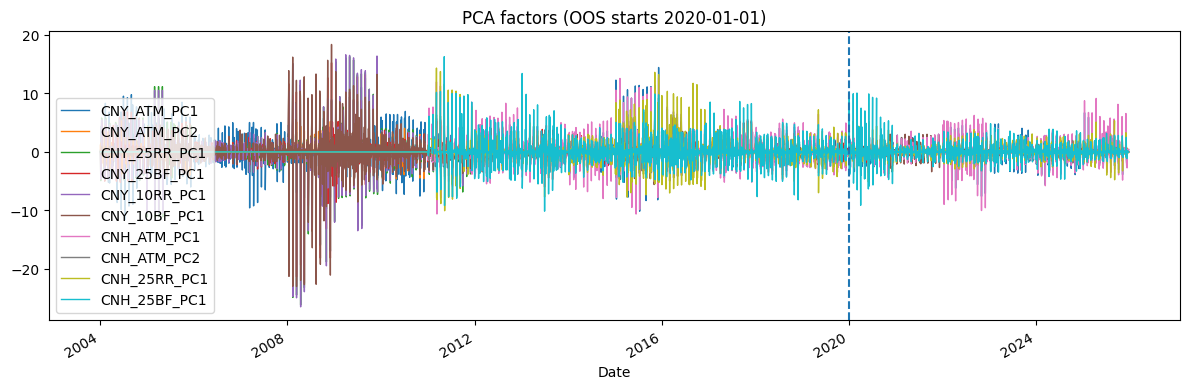

In [10]:
FACTOR_COLS = [c for c in panel_factors.columns if re.match(r"^(CNY|CNH)_(ATM|25RR|25BF|10RR|10BF)_PC\d+$", str(c))]
print("Factor cols:", len(FACTOR_COLS))

plt.figure(figsize=(12,4))
panel_factors[FACTOR_COLS].plot(ax=plt.gca(), lw=1)
plt.axvline(OOS_START, ls="--")
plt.title("PCA factors (OOS starts 2020-01-01)")
plt.tight_layout()
plt.show()

,factor,sample,n,phi1,tstat_phi1,R2
18,CNH_25BF_PC1,IS,4308,-0.154651,-10.271758,0.023917
19,CNH_25BF_PC1,OOS,1619,-0.276412,-11.565685,0.076404
16,CNH_25RR_PC1,IS,4308,-0.132687,-8.784635,0.017606
17,CNH_25RR_PC1,OOS,1619,-0.238181,-9.861519,0.056730
12,CNH_ATM_PC1,IS,4308,-0.128655,-8.513095,0.016552
13,CNH_ATM_PC1,OOS,1619,-0.071114,-2.866828,0.005057
14,CNH_ATM_PC2,IS,4308,-0.262248,-17.832886,0.068774
15,CNH_ATM_PC2,OOS,1619,-0.193226,-7.919103,0.037335
10,CNY_10BF_PC1,IS,4308,-0.207115,-13.892110,0.042896
11,CNY_10BF_PC1,OOS,1619,-0.221147,-9.119100,0.048912


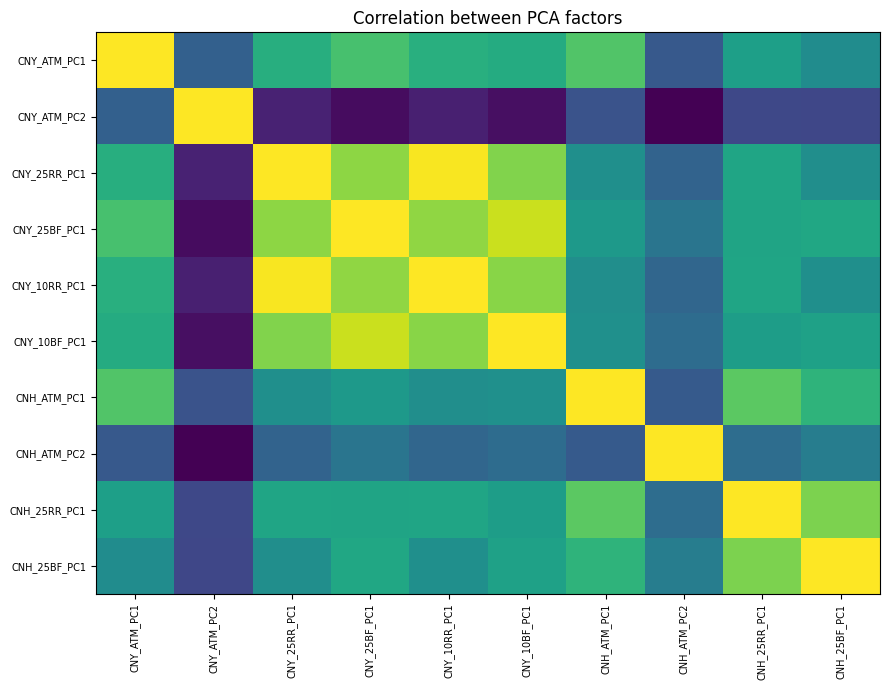

In [11]:
import statsmodels.api as sm

idx = panel_factors.index
is_mask  = idx <= IS_END
oos_mask = idx >= OOS_START

ar_rows = []
for c in FACTOR_COLS:
    for tag, mask in [("IS", is_mask), ("OOS", oos_mask)]:
        s = panel_factors.loc[mask, c].dropna().astype(float)
        if len(s) < 200:
            continue
        y = s.iloc[1:].values
        X = sm.add_constant(s.iloc[:-1].values)
        res = sm.OLS(y, X).fit()
        ar_rows.append({"factor": c, "sample": tag, "n": len(y),
                        "phi1": float(res.params[1]), "tstat_phi1": float(res.tvalues[1]),
                        "R2": float(res.rsquared)})

ar_df = pd.DataFrame(ar_rows).sort_values(["factor","sample"])
display(ar_df)

corr = panel_factors[FACTOR_COLS].corr()
plt.figure(figsize=(9,7))
plt.imshow(corr.values, aspect="auto", interpolation="nearest")
plt.xticks(range(len(FACTOR_COLS)), FACTOR_COLS, rotation=90, fontsize=7)
plt.yticks(range(len(FACTOR_COLS)), FACTOR_COLS, fontsize=7)
plt.title("Correlation between PCA factors")
plt.tight_layout()
plt.show()

## 5. Residual Construction (Mean Models)

Each PCA factor is first **de-meaned** using explainable models.

The resulting **standardised residuals** are the inputs to all volatility models.


In [12]:
def _as_clean_series(x: pd.Series) -> pd.Series:
    s = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    s = s.sort_index()
    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Series index must be DatetimeIndex.")
    s = s[~s.index.duplicated(keep="last")]
    return s

def standardise_resid(resid: pd.Series, end_idx: pd.Timestamp) -> tuple[pd.Series, float]:
    r = _as_clean_series(resid).astype(float)
    r_est = r.loc[:end_idx]
    sd = float(r_est.std(ddof=0))
    if (not np.isfinite(sd)) or sd <= 0:
        sd = 1.0
    r_std = (r / sd)
    r_std.name = f"{getattr(resid, 'name', 'resid')}_std"
    return r_std, sd

def rv_proxy(r: pd.Series, window: int) -> pd.Series:
    r2 = (r.astype(float) ** 2)
    return r2.rolling(window, min_periods=window).mean()

def logrv_proxy(r: pd.Series, window: int) -> pd.Series:
    return np.log(rv_proxy(r, window).clip(EPS))

def qlike(y: pd.Series, yhat: pd.Series) -> float:
    s = yhat.reindex(y.index).astype(float).clip(lower=EPS)
    y = y.astype(float)
    return float(np.mean(np.log(s) + y / s))

def corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    if len(df) < 5:
        return np.nan
    return float(df.corr().iloc[0, 1])

## 6. Volatility Modelling on Factor Residuals

All models operate on **standardised residuals**, estimated using IS statistics only.

### 6.1 GARCH(1,1)
- Rolling estimation
- Refitted monthly
- One-step-ahead conditional variance

### 6.2 MIDAS-GARCH
- Long-run component driven by monthly realised variance
- Beta-weighted lag structure
- Fully no-look-ahead design

### 6.3 HAR-X (preferred)
- Forecast target: log(RV\_{t+1})
- Core HAR terms:
  - Daily
  - Weekly
  - Monthly RV
- Augmented with macro / policy drivers
- Chosen for:
  - Stability
  - Interpretability
  - Attribution clarity


In [13]:
@dataclass
class GarchFit:
    omega: float
    alpha: float
    beta: float

def _fit_garch11_params(r_est: pd.Series, maxiter: int = 3000) -> GarchFit:
    y = r_est.astype(float).values
    if len(y) < 400:
        raise ValueError("Too few points to fit GARCH(1,1).")

    def _unpack(z):
        zw, za, zb = z
        omega = np.exp(zw) + 1e-12
        ea, eb = np.exp(za), np.exp(zb)
        denom = 1.0 + ea + eb
        alpha = ea / denom
        beta  = eb / denom
        return omega, alpha, beta

    def _nll(z):
        omega, alpha, beta = _unpack(z)
        T = len(y)
        sig2 = np.empty(T, dtype=float)
        sig2[0] = np.var(y) + 1e-12
        for t in range(1, T):
            sig2[t] = omega + alpha * (y[t-1] ** 2) + beta * sig2[t-1]
            if (not np.isfinite(sig2[t])) or sig2[t] <= 0:
                return 1e50
        ll = -0.5 * (np.log(2*np.pi) + np.log(sig2) + (y**2)/sig2)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return float(-np.sum(ll))

    z0 = np.array([np.log(np.var(y)*0.1 + 1e-12), np.log(0.05), np.log(0.90)], dtype=float)
    opt = minimize(_nll, z0, method="L-BFGS-B", options={"maxiter": maxiter, "ftol": 1e-10})
    if not opt.success:
        raise RuntimeError(f"GARCH(1,1) fit failed: {opt.message}")

    omega, alpha, beta = _unpack(opt.x)
    return GarchFit(float(omega), float(alpha), float(beta))

def _filter_garch11_one_step(r_seg: pd.Series, fit: GarchFit, init_sig2: float) -> pd.Series:
    y = r_seg.astype(float).values
    idx = r_seg.index

    sig2_hat = np.empty(len(y), dtype=float)
    sig2_hat[0] = float(init_sig2)

    for t in range(1, len(y)):
        sig2_hat[t] = fit.omega + fit.alpha * (y[t-1] ** 2) + fit.beta * sig2_hat[t-1]
        if (not np.isfinite(sig2_hat[t])) or sig2_hat[t] <= 0:
            sig2_hat[t] = EPS

    return pd.Series(sig2_hat, index=idx, name="GARCH11_sigma2_hat")

def rolling_garch11_forecast(
    r: pd.Series,
    oos_start: pd.Timestamp,
    lookback: int = 1260,
    refit_every: int = 21,
) -> pd.Series:
    r = _as_clean_series(r).astype(float)
    idx = r.index

    start_i = idx.get_indexer([oos_start], method="bfill")[0]
    sig2_out = pd.Series(index=idx, dtype=float)

    i = start_i
    while i < len(idx):
        end_fit_i = i - 1
        if end_fit_i <= 10:
            i += refit_every
            continue

        fit_start_i = max(0, end_fit_i - lookback + 1)
        r_est = r.iloc[fit_start_i : end_fit_i + 1]
        fit = _fit_garch11_params(r_est)

        j = min(len(idx), i + refit_every)
        r_seg = r.iloc[i:j]

        init_sig2 = float((r_est ** 2).mean())
        seg_sig2 = _filter_garch11_one_step(r_seg, fit, init_sig2=init_sig2)

        sig2_out.loc[seg_sig2.index] = seg_sig2
        i = j

    sig2_out.name = "GARCH(1,1)"
    return sig2_out

In [14]:
@dataclass
class MidasFit:
    alpha: float
    beta: float
    m: float
    theta: float
    omega2: float
    K: int
    omega1_fixed: float

def _beta_weights(K: int, omega1: float, omega2: float) -> np.ndarray:
    k = np.arange(1, K + 1, dtype=float)
    a, b = float(omega1), float(omega2)
    num = (k / K) ** (a - 1.0) * (1.0 - k / K) ** (b - 1.0)
    num = np.clip(num, 1e-18, np.inf)
    return num / np.sum(num)

def _monthly_rv_from_daily(r: pd.Series, how: str = "sum") -> pd.Series:
    r = _as_clean_series(r).astype(float)
    sq = (r ** 2)
    if how == "sum":
        return sq.resample("ME").sum()
    if how == "mean":
        return sq.resample("ME").mean()
    raise ValueError("how must be 'sum' or 'mean'")

def _build_daily_midas_lags_no_lookahead(
    daily_idx: pd.DatetimeIndex,
    monthly_x: pd.Series,
    K: int,
) -> pd.DataFrame:
    mx = monthly_x.sort_index().copy()
    X_m = pd.concat({f"x_lag{k}": mx.shift(k) for k in range(1, K + 1)}, axis=1)

    days = pd.DataFrame({"Date": pd.DatetimeIndex(daily_idx).sort_values()})
    months = X_m.reset_index().rename(columns={"index": "Date"}).sort_values("Date")

    X_daily = pd.merge_asof(
        days, months, on="Date", direction="backward", allow_exact_matches=False
    ).set_index("Date")
    return X_daily

def _make_midas_design_endogenous(
    r: pd.Series,
    end_fit_date: pd.Timestamp,
    K: int = 12,
    rv_how: str = "sum",
) -> pd.DataFrame:
    rv_m = _monthly_rv_from_daily(r, how=rv_how)
    x_m = np.log(rv_m.clip(EPS))

    x_est = x_m.loc[x_m.index <= end_fit_date]
    mu = float(x_est.mean())
    sd = float(x_est.std(ddof=0))
    if (not np.isfinite(sd)) or sd <= 0:
        sd = 1.0

    x_z = (x_m - mu) / sd
    Xlags = _build_daily_midas_lags_no_lookahead(r.index, x_z, K=K)
    Xlags.attrs["mu"] = mu
    Xlags.attrs["sd"] = sd
    return Xlags

def _fit_midas_garch_params(
    r_est: pd.Series,
    X_est: pd.DataFrame,
    K: int,
    omega1_fixed: float = 1.0,
    maxiter: int = 6000,
    n_starts: int = 6,
) -> MidasFit:
    y = r_est.astype(float).values
    Xmat = X_est.astype(float).values

    def _unpack(z):
        za, zb, zm, zt, zow2 = z
        ea, eb = np.exp(za), np.exp(zb)
        denom = 1.0 + ea + eb
        a = ea / denom
        b = eb / denom
        m = zm
        theta = zt
        omega2 = 1.01 + np.exp(zow2)
        return a, b, m, theta, omega2

    def _nll(z):
        a, b, m, theta, omega2 = _unpack(z)
        w = _beta_weights(K, omega1_fixed, omega2)
        mid = Xmat @ w
        tau = np.exp(np.clip(m + theta * mid, -50, 50))

        T = len(y)
        g = np.empty(T, dtype=float)
        g[0] = 1.0
        for t in range(1, T):
            tau_tm1 = max(tau[t-1], EPS)
            g[t] = (1.0 - a - b) + a * (y[t-1] ** 2 / tau_tm1) + b * g[t-1]
            if (not np.isfinite(g[t])) or g[t] <= 0:
                return 1e50

        sig2 = np.clip(tau * g, EPS, np.inf)
        ll = -0.5 * (np.log(2*np.pi) + np.log(sig2) + (y**2)/sig2)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return float(-np.sum(ll))

    base = np.array([np.log(0.05), np.log(0.90), np.log(np.var(y) + 1e-8), 0.0, np.log(2.0)], dtype=float)
    rng = np.random.default_rng(0)
    starts = [base] + [base + rng.normal(0.0, 0.8, size=base.size) for _ in range(max(0, n_starts - 1))]

    best = None
    for z0 in starts:
        opt = minimize(_nll, z0, method="L-BFGS-B", options={"maxiter": maxiter, "ftol": 1e-10})
        if best is None or (opt.success and opt.fun < best.fun):
            best = opt

    if (best is None) or (not best.success):
        nm = minimize(_nll, base, method="Nelder-Mead", options={"maxiter": maxiter, "xatol": 1e-6, "fatol": 1e-6})
        if best is None or (nm.success and nm.fun < best.fun):
            best = nm

    if (best is None) or (not best.success):
        raise RuntimeError(f"MIDAS-GARCH fit failed: {best.message if best is not None else 'no result'}")

    a, b, m, theta, omega2 = _unpack(best.x)
    return MidasFit(float(a), float(b), float(m), float(theta), float(omega2), K=int(K), omega1_fixed=float(omega1_fixed))

def _filter_midas_garch_one_step(
    r_seg: pd.Series,
    X_seg: pd.DataFrame,
    fit: MidasFit,
    init_g: float = 1.0,
) -> pd.Series:
    y = r_seg.astype(float).values
    Xmat = X_seg.astype(float).values

    w = _beta_weights(fit.K, fit.omega1_fixed, fit.omega2)
    mid = Xmat @ w
    tau = np.exp(np.clip(fit.m + fit.theta * mid, -50, 50))

    g = np.empty(len(y), dtype=float)
    g[0] = float(init_g)

    sig2_hat = np.empty(len(y), dtype=float)
    sig2_hat[0] = max(tau[0] * g[0], EPS)

    for t in range(1, len(y)):
        tau_tm1 = max(tau[t-1], EPS)
        g[t] = (1.0 - fit.alpha - fit.beta) + fit.alpha * (y[t-1] ** 2 / tau_tm1) + fit.beta * g[t-1]
        if (not np.isfinite(g[t])) or g[t] <= 0:
            g[t] = EPS
        sig2_hat[t] = max(tau[t] * g[t], EPS)

    return pd.Series(sig2_hat, index=r_seg.index, name="MIDAS-GARCH_sigma2_hat")

def rolling_midas_garch_forecast(
    r: pd.Series,
    oos_start: pd.Timestamp,
    lookback: int = 1800,
    refit_every: int = 21,
    K: int = 12,
    rv_how: str = "sum",
    omega1_fixed: float = 1.0,
) -> pd.Series:
    r = _as_clean_series(r).astype(float)
    idx = r.index

    start_i = idx.get_indexer([oos_start], method="bfill")[0]
    sig2_out = pd.Series(index=idx, dtype=float)

    i = start_i
    while i < len(idx):
        end_fit_i = i - 1
        if end_fit_i <= 30:
            i += refit_every
            continue

        fit_start_i = max(0, end_fit_i - lookback + 1)
        r_est = r.iloc[fit_start_i : end_fit_i + 1]
        end_fit_date = idx[end_fit_i]

        X_all = _make_midas_design_endogenous(r, end_fit_date=end_fit_date, K=K, rv_how=rv_how)
        X_est = X_all.loc[r_est.index]

        good_est = X_est.notna().all(axis=1)
        r_est2 = r_est.loc[good_est]
        X_est2 = X_est.loc[good_est]

        if len(r_est2) < 600:
            i += refit_every
            continue

        fit = _fit_midas_garch_params(r_est2, X_est2, K=K, omega1_fixed=omega1_fixed)

        j = min(len(idx), i + refit_every)
        r_seg = r.iloc[i:j]
        X_seg = X_all.loc[r_seg.index]

        good_seg = X_seg.notna().all(axis=1)
        r_seg2 = r_seg.loc[good_seg]
        X_seg2 = X_seg.loc[good_seg]

        if len(r_seg2) > 0:
            seg_sig2 = _filter_midas_garch_one_step(r_seg2, X_seg2, fit, init_g=1.0)
            sig2_out.loc[seg_sig2.index] = seg_sig2

        i = j

    sig2_out.name = "MIDAS-GARCH"
    return sig2_out


In [15]:
def pick_macro_exog_cols(df: pd.DataFrame) -> list[str]:
    """
    Macro/risk drivers only (avoid sparse CNH surface change blocks).
    """
    keep_prefix = (
        "RET_DRV_", "CHG_DRV_",
        "RET_POL_", "CHG_POL_",
        "RET_CN_",  "CHG_CN_",
        "RET_US_",  "CHG_US_",
        "RET_OTH_", "CHG_OTH_",
        "FEAT_",
        "RET_CNY_SPOT", "RET_CNH_SPOT",
    )

    cols = []
    for c in df.columns.astype(str):
        if c.startswith("CHG_CNH_") or (c.startswith("RET_CNH_") and c != "RET_CNH_SPOT"):
            continue
        if c.startswith("CHG_CNY_") or (c.startswith("RET_CNY_") and c != "RET_CNY_SPOT"):
            continue
        if c.startswith(keep_prefix):
            cols.append(c)

    out, seen = [], set()
    for c in cols:
        if c in df.columns and c not in seen:
            out.append(c); seen.add(c)
    return out

def _clean_exog_block(
    Xe: pd.DataFrame,
    min_non_nan_frac: float = 0.90,
    max_abs_clip: float | None = None,
) -> pd.DataFrame:
    Xe = Xe.copy()
    for c in Xe.columns:
        Xe[c] = pd.to_numeric(Xe[c], errors="coerce")
    Xe = Xe.replace([np.inf, -np.inf], np.nan)

    if max_abs_clip is not None:
        Xe = Xe.clip(lower=-float(max_abs_clip), upper=float(max_abs_clip))

    keep = Xe.notna().mean(axis=0) >= float(min_non_nan_frac)
    Xe = Xe.loc[:, keep]

    # no-leak fills:
    retchg = [c for c in Xe.columns if str(c).startswith(("RET_", "CHG_"))]
    other  = [c for c in Xe.columns if c not in retchg]

    if other:
        Xe[other] = Xe[other].ffill()          # NO bfill
    if retchg:
        Xe[retchg] = Xe[retchg].fillna(0.0)    # missing return/change -> 0

    nunq = Xe.nunique(dropna=True)
    Xe = Xe.loc[:, nunq > 1]
    return Xe

def _harx_design(r: pd.Series, X_exog: pd.DataFrame | None, rv_window: int):
    r = _as_clean_series(r).astype(float)
    r2 = r ** 2

    rv_d = r2
    rv_w = r2.rolling(5,  min_periods=5).mean()
    rv_m = r2.rolling(22, min_periods=22).mean()

    X_core = pd.DataFrame({
        "log_rv_d": np.log(rv_d.clip(EPS)),
        "log_rv_w": np.log(rv_w.clip(EPS)),
        "log_rv_m": np.log(rv_m.clip(EPS)),
    }, index=r.index).replace([np.inf, -np.inf], np.nan)

    y = logrv_proxy(r, rv_window)
    y_next = y.shift(-1).rename("y_next")

    X = X_core
    if X_exog is not None:
        Xe = _clean_exog_block(X_exog.reindex(r.index), min_non_nan_frac=0.90, max_abs_clip=None)
        X = pd.concat([X, Xe], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan)
    df = pd.concat([y_next, X], axis=1).dropna()

    y_aligned = df["y_next"]
    X_aligned = df.drop(columns=["y_next"])

    nunq = X_aligned.nunique(dropna=True)
    X_aligned = X_aligned.loc[:, nunq > 1]
    return X_aligned, y_aligned

def rolling_harx_logrv_forecast(
    r: pd.Series,
    X_exog: pd.DataFrame | None,
    oos_start: pd.Timestamp,
    rv_window: int = 5,
    lookback: int = 1260,
    refit_every: int = 21,
) -> pd.Series:
    r = _as_clean_series(r).astype(float)
    idx = r.index

    X_all, y_all = _harx_design(r, X_exog=X_exog, rv_window=rv_window)
    yhat_next = pd.Series(index=y_all.index, dtype=float)

    start_i = idx.get_indexer([oos_start], method="bfill")[0]
    i = start_i

    while i < len(idx):
        t_date = idx[i]
        end_fit_date = idx[i - 1] if i > 0 else t_date
        j_date = idx[min(len(idx) - 1, i + refit_every - 1)]

        df_fit = pd.concat([y_all, X_all], axis=1).loc[:end_fit_date].dropna()
        if len(df_fit) < 400:
            i += refit_every
            continue

        df_fit = df_fit.iloc[-lookback:] if len(df_fit) > lookback else df_fit
        Y = df_fit.iloc[:, 0]
        Xmat = df_fit.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna()
        Y = Y.reindex(Xmat.index)

        if len(Xmat) < 250:
            i += refit_every
            continue

        Xis = sm.add_constant(Xmat, has_constant="add")
        fit = sm.OLS(Y.values, Xis.values).fit()

        df_pred = X_all.loc[t_date:j_date].replace([np.inf, -np.inf], np.nan).dropna()
        if len(df_pred) > 0:
            Xp = sm.add_constant(df_pred, has_constant="add")
            yhat_next.loc[df_pred.index] = fit.predict(Xp.values)

        i += refit_every

    yhat_next.name = f"HAR-X_logRV_w{rv_window}"
    return yhat_next

def harx_logrv_to_sig2hat(yhat_logrv_next: pd.Series, rv_window: int = 5) -> pd.Series:
    """
    yhat_logrv_next[t] forecasts logRV_{t+1} (built that way in _harx_design).
    Convert to RV level forecast and align to date (t+1) by shifting +1.
    """
    rv_hat_next = np.exp(yhat_logrv_next).rename("HARX_RV_hat_next")
    rv_hat = rv_hat_next.shift(1).rename("HAR-X")
    return rv_hat


In [34]:
def run_rolling_vol_suite(
    resid_raw: pd.Series,
    X_exog: pd.DataFrame | None,
    is_end: pd.Timestamp,
    oos_start: pd.Timestamp,
    rv_window: int = 5,
    lookback: int = 1260,
    refit_every: int = 21,
    midas_K: int = 12,
    midas_rv_how: str = "sum",
):
    r, sd = standardise_resid(resid_raw, is_end=is_end)


    sig2_garch = rolling_garch11_forecast(r, oos_start=oos_start, lookback=lookback, refit_every=refit_every)
    sig2_midas = rolling_midas_garch_forecast(
        r, oos_start=oos_start, lookback=max(lookback, 1800),
        refit_every=refit_every, K=midas_K, rv_how=midas_rv_how
    )

    yhat_harx_logrv = rolling_harx_logrv_forecast(
        r, X_exog=X_exog, oos_start=oos_start, rv_window=rv_window,
        lookback=lookback, refit_every=refit_every
    )
    rvhat_harx = harx_logrv_to_sig2hat(yhat_harx_logrv, rv_window=rv_window)

    rvhat_garch = sig2_garch.rolling(rv_window, min_periods=rv_window).mean()
    rvhat_midas = sig2_midas.rolling(rv_window, min_periods=rv_window).mean()
    rv_real = rv_proxy(r, rv_window)

    rv_real_oos = rv_real.loc[rv_real.index >= oos_start].dropna()

    rows = []
    for name, rvhat in {
        "GARCH(1,1)": rvhat_garch,
        "MIDAS-GARCH": rvhat_midas,
        "HAR-X": rvhat_harx,
    }.items():
        rvhat_oos = rvhat.reindex(rv_real_oos.index).dropna()
        rows.append({
            "model": name,
            "n_oos": int(len(rv_real_oos)),
            "Corr_logRV": corr(np.log(rv_real_oos.clip(EPS)), np.log(rvhat_oos.clip(EPS))),
            "QLIKE_RV": qlike(rv_real_oos, rvhat.reindex(rv_real_oos.index).clip(EPS)),
        })

    out_df = pd.DataFrame(rows).sort_values(["QLIKE_RV"]).reset_index(drop=True)
    return out_df, {
        "r_std": r,
        "sig2_garch": sig2_garch,
        "sig2_midas": sig2_midas,
        "rvhat_harx": rvhat_harx,
    }


## 7. Model Evaluation (OOS)

Evaluated strictly post-2020 using:
- **QLIKE** (variance loss)
- **Correlation of log RV**
- Rolling RV window = 5 days

Models compared:
- GARCH(1,1)
- MIDAS-GARCH
- HAR-X

In [35]:
def eval_all_models_for_factor(resid_raw: pd.Series, is_end: pd.Timestamp, oos_start: pd.Timestamp, midas_K: int = 12) -> pd.DataFrame:
    # standardise once
    r_std, _ = standardise_resid(_as_clean_series(resid_raw), is_end)

    # baselines
    sig2_is = float((r_std.loc[:is_end] ** 2).mean())
    base = {
        "UNCOND":      forecast_uncond(sig2_is, r_std.index),
        "EWMA_0.94":   forecast_ewma(r_std, 0.94),
        "ROLLVAR_20":  forecast_rollvar(r_std, 20),
        "HAR_RV":      forecast_har_rv(r_std, is_end),
    }

    # vol models
    g = fit_forecast_garch11(r_std, is_end=is_end, oos_start=oos_start)
    try:
        m = fit_forecast_midas_garch(r_std, is_end=is_end, oos_start=oos_start, K=midas_K)
    except Exception:
        m = None

    preds = dict(base)
    preds["GARCH(1,1)"] = g.sigma2_hat.reindex(r_std.index)
    if m is not None:
        preds["MIDAS-GARCH"] = m.sigma2_hat.reindex(r_std.index)

    rows = []
    for name, s2 in preds.items():
        met = eval_one_forecast(r_std, s2, oos_start)
        rows.append({"model": name, **met})

    return pd.DataFrame(rows).sort_values("QLIKE_daily").reset_index(drop=True)



In [36]:
def forecast_uncond(sig2_is: float, idx: pd.DatetimeIndex) -> pd.Series:
    return pd.Series(sig2_is, index=idx, name="UNCOND")

def forecast_ewma(r: pd.Series, lam: float = 0.94) -> pd.Series:
    r = r.astype(float)
    s2 = pd.Series(index=r.index, dtype=float)
    s2.iloc[0] = float(r.var(ddof=0))
    for t in range(1, len(r)):
        s2.iloc[t] = lam * s2.iloc[t-1] + (1.0 - lam) * (r.iloc[t-1] ** 2)
    s2.name = f"EWMA_{lam}"
    return s2

def forecast_rollvar(r: pd.Series, window: int = 20) -> pd.Series:
    s2 = (r.astype(float) ** 2).rolling(window, min_periods=window).mean().shift(1)
    s2.name = f"ROLLVAR_{window}"
    return s2

def forecast_har_rv(r: pd.Series, is_end: pd.Timestamp) -> pd.Series:
    """
    HAR on log RV proxies:
      log(RV_{t+1}) ~ const + log(RV^D_t) + log(RV^W_t) + log(RV^M_t)
    where RV^D_t = r_t^2, RV^W_t = mean_{5} r^2, RV^M_t = mean_{22} r^2
    """
    r2 = (r.astype(float) ** 2)
    rv_d = r2
    rv_w = r2.rolling(5,  min_periods=5).mean()
    rv_m = r2.rolling(22, min_periods=22).mean()

    X = pd.concat([
        np.log(rv_d.clip(1e-18)),
        np.log(rv_w.clip(1e-18)),
        np.log(rv_m.clip(1e-18)),
    ], axis=1)
    X.columns = ["log_rv_d", "log_rv_w", "log_rv_m"]

    y = np.log(rv_d.shift(-1).clip(1e-18))  # next-day variance proxy

    df = pd.concat([y, X], axis=1).dropna()
    df_is = df.loc[:is_end]
    if len(df_is) < 400:
        raise ValueError("Too few IS rows for HAR.")

    Y = df_is.iloc[:, 0].values
    Xis = sm.add_constant(df_is.iloc[:, 1:].values)
    fit = sm.OLS(Y, Xis).fit()

    Xfull = sm.add_constant(df.iloc[:, 1:].values)
    yhat_log = fit.predict(Xfull)
    sig2_hat = np.exp(yhat_log)

    out = pd.Series(sig2_hat, index=df.index, name="HAR_RV")
    # align to full index, and interpret as variance forecast for t+1 (already shifted in y)
    return out.reindex(r.index)


In [37]:
@dataclass
class VolForecastResult:
    sigma2_hat: pd.Series
    meta: dict

def _as_clean_series(x: pd.Series) -> pd.Series:
    s = pd.to_numeric(x, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    s = s.sort_index()
    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Series index must be DatetimeIndex.")
    s = s[~s.index.duplicated(keep="last")]
    return s

def _is_sd(resid: pd.Series, is_end: pd.Timestamp) -> float:
    r = resid.loc[:is_end].dropna().astype(float)
    sd = float(r.std(ddof=0))
    return sd if (np.isfinite(sd) and sd > 0) else 1.0

def standardise_resid(resid: pd.Series, is_end: pd.Timestamp) -> tuple[pd.Series, float]:
    sd = _is_sd(resid, is_end)
    r = resid.astype(float) / sd
    r.name = f"{resid.name}_std"
    return r, sd

def rv_proxy(r: pd.Series, window: int) -> pd.Series:
    r2 = (r.astype(float) ** 2)
    return r2.rolling(window, min_periods=window).mean()

def qlike(y: pd.Series, sig2: pd.Series) -> float:
    s = sig2.reindex(y.index).astype(float).clip(lower=1e-18)
    y = y.astype(float)
    return float(np.mean(np.log(s) + y / s))


In [38]:
def fit_forecast_garch11(
    resid: pd.Series,
    is_end: pd.Timestamp,
    oos_start: pd.Timestamp,
    maxiter: int = 4000,
    scale_is: bool = True,
) -> VolForecastResult:
    r = _as_clean_series(resid).astype(float)
    r_is = r.loc[:is_end].astype(float)
    if len(r_is) < 500:
        raise ValueError(f"Too few IS observations for GARCH(1,1): {len(r_is)}")

    s_is = float(r_is.std(ddof=0))
    if (not np.isfinite(s_is)) or (s_is <= 0):
        s_is = 1.0
    scale = s_is if scale_is else 1.0

    y = (r_is / scale).values

    def _unpack(z):
        zw, za, zb = z
        omega = np.exp(zw) + 1e-12
        ea, eb = np.exp(za), np.exp(zb)
        denom = 1.0 + ea + eb
        alpha = ea / denom
        beta  = eb / denom
        return omega, alpha, beta

    def _nll(z):
        omega, alpha, beta = _unpack(z)
        T = len(y)
        sig2 = np.empty(T, dtype=float)
        sig2[0] = np.var(y) + 1e-12
        for t in range(1, T):
            sig2[t] = omega + alpha * (y[t - 1] ** 2) + beta * sig2[t - 1]
            if not np.isfinite(sig2[t]) or sig2[t] <= 0:
                return 1e50
        ll = -0.5 * (np.log(2.0 * np.pi) + np.log(sig2) + (y ** 2) / sig2)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return float(-np.sum(ll))

    z0 = np.array([np.log(np.var(y) * 0.1 + 1e-12), np.log(0.05), np.log(0.90)], dtype=float)
    opt = minimize(_nll, z0, method="L-BFGS-B", options={"maxiter": maxiter, "ftol": 1e-10})
    if not opt.success:
        raise RuntimeError(f"GARCH(1,1) optimisation failed: {opt.message}")

    omega, alpha, beta = _unpack(opt.x)

    y_full = (r / scale).values
    T = len(y_full)
    sig2 = np.empty(T, dtype=float)
    sig2[0] = np.var(y) + 1e-12
    for t in range(1, T):
        sig2[t] = omega + alpha * (y_full[t - 1] ** 2) + beta * sig2[t - 1]
        if not np.isfinite(sig2[t]) or sig2[t] <= 0:
            sig2[t] = 1e-18

    sigma2_hat = pd.Series(sig2 * (scale ** 2), index=r.index, name="GARCH11_sigma2_hat")
    sigma2_oos = sigma2_hat.loc[sigma2_hat.index >= oos_start].copy()

    return VolForecastResult(
        sigma2_hat=sigma2_oos.astype(float),
        meta={
            "model": "GARCH(1,1)",
            "scale_is": float(scale),
            "params": {"omega": float(omega) * (scale ** 2), "alpha": float(alpha), "beta": float(beta)},
            "opt_nll": float(opt.fun),
        },
    )


In [39]:
def eval_one_forecast(r_std: pd.Series, s2_hat: pd.Series, oos_start: pd.Timestamp) -> dict:
    r_std = _as_clean_series(r_std)
    y2_d = (r_std ** 2).loc[r_std.index >= oos_start]
    y2_w = rv_proxy(r_std, 5).loc[r_std.index >= oos_start]

    s2_d = s2_hat.reindex(y2_d.index).astype(float).clip(lower=1e-18)
    s2_w = s2_hat.reindex(y2_w.index).astype(float).clip(lower=1e-18)

    corr_d = float(pd.concat([y2_d, s2_d], axis=1).corr().iloc[0, 1])
    corr_w = float(pd.concat([y2_w, s2_w], axis=1).dropna().corr().iloc[0, 1])

    return {
        "n_oos": int(len(y2_d)),
        "QLIKE_daily": qlike(y2_d, s2_d),
        "Corr_daily": corr_d,
        "QLIKE_week": qlike(y2_w.dropna(), s2_w.dropna()),
        "Corr_week": corr_w,
    }

def eval_all_models_for_factor(resid_raw: pd.Series, is_end: pd.Timestamp, oos_start: pd.Timestamp, midas_K: int = 12) -> pd.DataFrame:
    # standardise once
    r_std, _ = standardise_resid(_as_clean_series(resid_raw), is_end)

    # baselines
    sig2_is = float((r_std.loc[:is_end] ** 2).mean())
    base = {
        "UNCOND":      forecast_uncond(sig2_is, r_std.index),
        "EWMA_0.94":   forecast_ewma(r_std, 0.94),
        "ROLLVAR_20":  forecast_rollvar(r_std, 20),
        "HAR_RV":      forecast_har_rv(r_std, is_end),
    }

    # vol models
    g = fit_forecast_garch11(r_std, is_end=is_end, oos_start=oos_start)
    try:
        m = fit_forecast_midas_garch(r_std, is_end=is_end, oos_start=oos_start, K=midas_K)
    except Exception:
        m = None

    preds = dict(base)
    preds["GARCH(1,1)"] = g.sigma2_hat.reindex(r_std.index)
    if m is not None:
        preds["MIDAS-GARCH"] = m.sigma2_hat.reindex(r_std.index)

    rows = []
    for name, s2 in preds.items():
        met = eval_one_forecast(r_std, s2, oos_start)
        rows.append({"model": name, **met})

    return pd.DataFrame(rows).sort_values("QLIKE_daily").reset_index(drop=True)


In [40]:
from scipy.optimize import minimize


def make_ar1_residuals(panel_factors: pd.DataFrame, factor_cols: list, is_end: pd.Timestamp) -> dict:
    resid_map = {}
    for c in factor_cols:
        s = panel_factors[c].dropna().astype(float)
        s_is = s.loc[:is_end]
        if len(s_is) < 300:
            continue

        y = s_is.iloc[1:].values
        X = sm.add_constant(s_is.iloc[:-1].values)
        fit = sm.OLS(y, X).fit()

        c0, phi = float(fit.params[0]), float(fit.params[1])
        e = (s - (c0 + phi * s.shift(1))).dropna()
        resid_map[c] = e.rename(f"{c}_resid_AR1")
    return resid_map


resid_map = make_ar1_residuals(panel_factors, FACTOR_COLS, IS_END)
print("Residual series:", len(resid_map))

# sanity: one factor table (baselines + garch + midas)
test_fac = list(resid_map.keys())[0]
print("TEST FACTOR:", test_fac)
display(eval_all_models_for_factor(resid_map[test_fac], IS_END, OOS_START, midas_K=12))


Residual series: 10
TEST FACTOR: CNY_ATM_PC1


,model,n_oos,QLIKE_daily,Corr_daily,QLIKE_week,Corr_week
0,HAR_RV,1620,-1.302848,0.896883,10.884201,0.654364
1,EWMA_0.94,1620,0.205354,0.055794,-0.206051,0.575125
2,"GARCH(1,1)",1620,0.205541,0.028488,0.034568,0.689253
3,UNCOND,1620,0.412226,NaN,0.412199,NaN
4,ROLLVAR_20,1620,0.872919,-0.023509,0.100164,0.312945


In [41]:
exog_cols = pick_macro_exog_cols(panel_factors)
X_exog = panel_factors[exog_cols].copy()

Xe = X_exog.replace([np.inf, -np.inf], np.nan)
arr = Xe.to_numpy(dtype=float, copy=True) if Xe.shape[1] > 0 else np.empty((len(Xe), 0))
bad_cols = Xe.columns[~np.isfinite(arr).all(axis=0)] if Xe.shape[1] > 0 else []
print("Cols containing inf (pre-clean):", list(bad_cols))
print("Top NaN fraction cols (pre-clean):\n", Xe.isna().mean().sort_values(ascending=False).head(15))

# pick factor residual
fac = list(resid_map.keys())[0]
resid = resid_map[fac]

if ("CNH_START" in globals()) and (CNH_START is not None) and str(fac).startswith("CNH_"):
    resid = resid.loc[resid.index >= CNH_START].copy()
    X_exog = X_exog.loc[X_exog.index >= CNH_START].copy()

res_table, artifacts = run_rolling_vol_suite(
    resid_raw=resid,
    X_exog=X_exog,
    is_end=IS_END,
    oos_start=OOS_START,
    rv_window=5,
    lookback=1260,
    refit_every=21,
    midas_K=12,
    midas_rv_how="sum",
)

display(res_table)

Cols containing inf (pre-clean): ['RET_CNH_SPOT', 'RET_DRV_S_P_500', 'RET_DRV_CFETS_RMB_INDEX', 'CHG_DRV_CN_10Y_YLD_bps', 'CHG_POL_FDTR_FED_FUNDS_bps', 'CHG_DRV_VIX_bps', 'CHG_DRV_CN_2Y_YLD_bps', 'CHG_POL_VXEEM_EM_VOL_bps', 'CHG_POL_GVZ_GOLD_VOL_bps']
Top NaN fraction cols (pre-clean):
 CHG_POL_VXEEM_EM_VOL_bps          0.326025
RET_CNH_SPOT                      0.300051
CHG_POL_GVZ_GOLD_VOL_bps          0.199022
CHG_DRV_CN_2Y_YLD_bps             0.063754
CHG_DRV_CN_10Y_YLD_bps            0.063417
RET_DRV_CFETS_RMB_INDEX           0.023444
RET_DRV_S_P_500                   0.000169
CHG_DRV_VIX_bps                   0.000169
CHG_POL_FDTR_FED_FUNDS_bps        0.000169
CHG_DRV_US_2Y_YLD_bps             0.000000
CHG_POL_MOVE_BOND_VOL_bps         0.000000
CHG_POL_CN_REPO_7D_ONSHORE_bps    0.000000
FEAT_CNY_Spot_Fix_Dev             0.000000
CHG_DRV_US_10Y_YLD_bps            0.000000
RET_CNY_SPOT                      0.000000
dtype: float64


KeyboardInterrupt: 

## 8. HAR-X Visual Diagnostics

### 8.1 Volatility overlay (from 2020)
- Actual realised vol (MA smoothed)
- HAR-X forecast vol
- IV PCA factor overlay (RHS axis)

Purpose:
- Visual regime alignment
- Structural validation


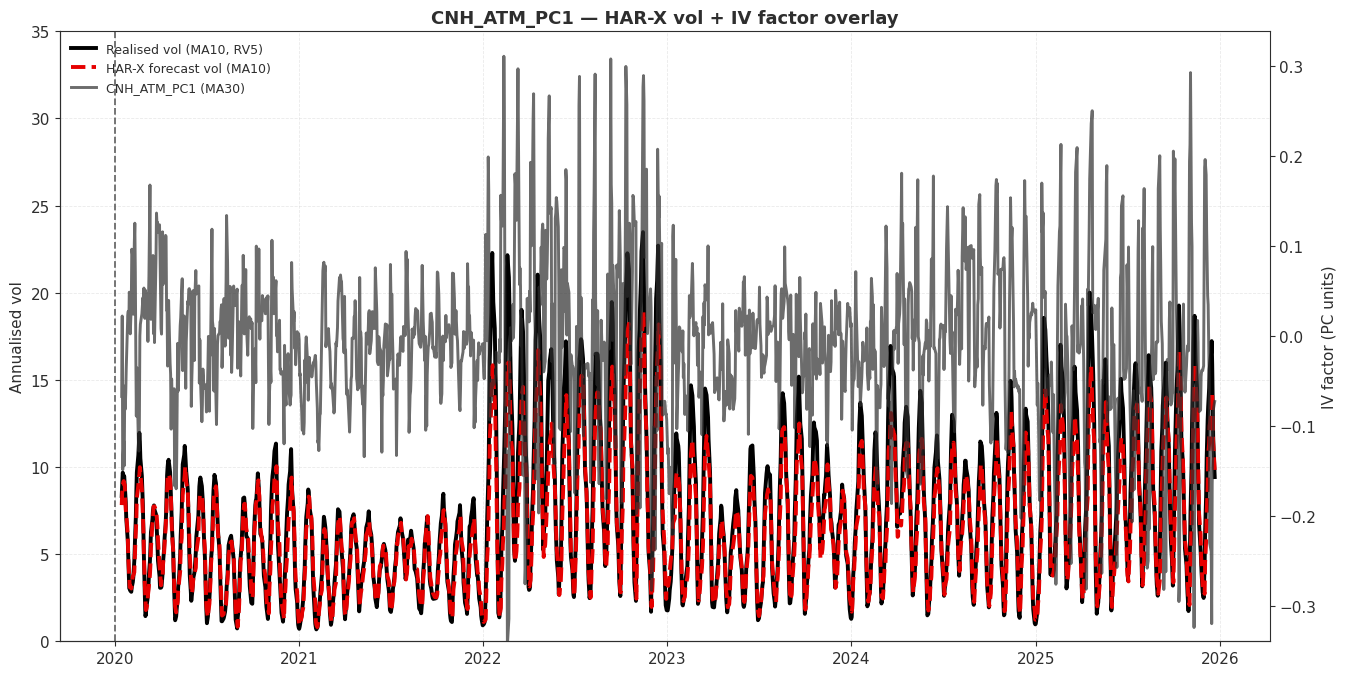

/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


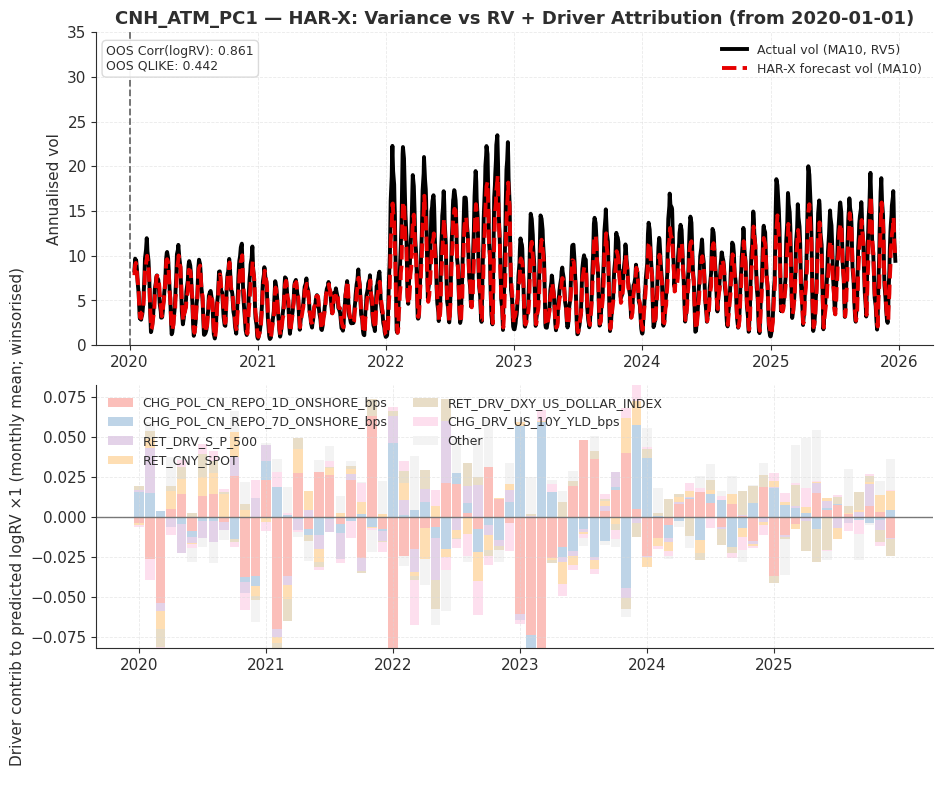

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


UBS_RED   = "#E60000"
DARK_GREY = "#2E2E2E"
MID_GREY  = "#6A6A6A"
GRID_GREY = "#D9D9D9"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": DARK_GREY,
    "axes.labelcolor": DARK_GREY,
    "xtick.color": DARK_GREY,
    "ytick.color": DARK_GREY,
    "text.color": DARK_GREY,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "grid.color": GRID_GREY,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

def _clean(ax):
    ax.grid(True, alpha=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

EPS = 1e-12

def _annualise_vol_from_rv(rv: pd.Series, ann_days: int = 252) -> pd.Series:
    return np.sqrt(rv.clip(EPS) * ann_days)

def _winsor_clip_series(s: pd.Series, qlo=0.01, qhi=0.99) -> pd.Series:
    s = s.astype(float)
    lo = float(s.quantile(qlo))
    hi = float(s.quantile(qhi))
    return s.clip(lo, hi)

def _winsor_clip_df(df: pd.DataFrame, qlo=0.01, qhi=0.99) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = _winsor_clip_series(out[c], qlo, qhi)
    return out

def _qlike(actual_var: pd.Series, forecast_var: pd.Series) -> float:
    a = actual_var.astype(float).clip(EPS)
    f = forecast_var.astype(float).clip(EPS)
    m = a.index.intersection(f.index)
    a, f = a.reindex(m), f.reindex(m)
    # QLIKE (variance): log(f) + a/f
    return float(np.nanmean(np.log(f.values) + (a.values / f.values)))

def _corr_logrv(actual_var: pd.Series, forecast_var: pd.Series) -> float:
    a = np.log(actual_var.astype(float).clip(EPS))
    f = np.log(forecast_var.astype(float).clip(EPS))
    m = a.index.intersection(f.index)
    a, f = a.reindex(m), f.reindex(m)
    return float(np.corrcoef(a.values, f.values)[0, 1])

def pick_macro_exog_cols(df: pd.DataFrame,
                         prefixes=("RET_", "CHG_", "FEAT_"),
                         drop_prefixes=("CHG_CNY_", "CHG_CNH_", "CNY_", "CNH_"),
                         max_nan_frac=0.35):
    cols = []
    for c in df.columns.astype(str):
        if c.startswith(prefixes) and (not c.startswith(drop_prefixes)):
            cols.append(c)
    if not cols:
        return []
    Xe = df[cols].replace([np.inf, -np.inf], np.nan)
    keep = (Xe.isna().mean() <= max_nan_frac)
    return list(keep[keep].index)


def plot_harx_iv_overlay_from_2020(
    factor_name: str,
    panel_factors: pd.DataFrame,
    artifacts: dict,
    oos_start: pd.Timestamp,
    window_start: str | pd.Timestamp = "2020-01-01",
    rv_window: int = 5,
    ma_vol: int = 10,
    ma_factor: int = 30,
    ann_days: int = 252,
    figsize: tuple[float, float] = (13.6, 6.9),
    force_vol_ylim: tuple[float, float] | None = (0.0, 35.0),
    title: str | None = None,
):
    ws = pd.Timestamp(window_start)

    r = artifacts["r_std"].copy()
    rv_real = rv_proxy(r, rv_window)
    rv_hat  = artifacts["rvhat_harx"].reindex(rv_real.index)

    vol_real = _annualise_vol_from_rv(rv_real, ann_days=ann_days).rolling(ma_vol).mean()
    vol_hat  = _annualise_vol_from_rv(rv_hat,  ann_days=ann_days).rolling(ma_vol).mean()

    fac = panel_factors[factor_name].reindex(vol_real.index).astype(float)
    fac_ma = fac.rolling(ma_factor).mean()

    df = pd.DataFrame({"vol_real": vol_real, "vol_hat": vol_hat, "fac_ma": fac_ma}).dropna()
    df = df.loc[df.index >= ws].copy()

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    ax.plot(df.index, df["vol_real"].values, color="black", lw=2.8,
            label=f"Realised vol (MA{ma_vol}, RV{rv_window})")
    ax.plot(df.index, df["vol_hat"].values, color=UBS_RED, lw=2.8, ls="--",
            label=f"HAR-X forecast vol (MA{ma_vol})")

    ax.axvline(oos_start, color=MID_GREY, ls="--", lw=1.3)
    ax.set_ylabel("Annualised vol")
    ax.set_title(title or f"{factor_name} — HAR-X vol + IV factor overlay (from {ws.date()})")
    _clean(ax)

    if force_vol_ylim is not None:
        ax.set_ylim(*force_vol_ylim)
    else:
        y_top = float(np.nanpercentile(df["vol_real"].values, 99.5))
        ax.set_ylim(0, max(5.0, 1.25 * y_top))

    ax2 = ax.twinx()
    ax2.plot(df.index, df["fac_ma"].values, color=DARK_GREY, lw=2.1, alpha=0.70,
             label=f"{factor_name} (MA{ma_factor})")
    ax2.set_ylabel("IV factor (PC units)")

    f = df["fac_ma"].values
    fmax = float(np.nanpercentile(np.abs(f), 99.5))
    ax2.set_ylim(-1.15 * fmax, 1.15 * fmax)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()
    return df

# Rolling HAR-X forecast (logRV_{t+1}) + attribution β·x[t]
def rolling_harx_logrv_forecast_with_attrib(
    r: pd.Series,
    X_exog: pd.DataFrame | None,
    oos_start: pd.Timestamp,
    rv_window: int = 5,
    lookback: int = 1260,
    refit_every: int = 21,
    min_fit_rows: int = 400,
):
    r = _as_clean_series(r).astype(float)
    idx = r.index

    X_all, y_all = _harx_design(r, X_exog=X_exog, rv_window=rv_window)
    yhat_next = pd.Series(index=y_all.index, dtype=float, name=f"HARX_logRV_next_w{rv_window}")
    contrib   = pd.DataFrame(index=y_all.index, columns=list(X_all.columns), dtype=float)

    start_i = idx.get_indexer([oos_start], method="bfill")[0]
    i = start_i

    while i < len(idx):
        t_date = idx[i]
        end_fit_date = idx[i - 1] if i > 0 else t_date
        j_date = idx[min(len(idx) - 1, i + refit_every - 1)]

        df_fit = pd.concat([y_all, X_all], axis=1).loc[:end_fit_date].dropna()
        if len(df_fit) < min_fit_rows:
            i += refit_every
            continue

        df_fit = df_fit.iloc[-lookback:] if len(df_fit) > lookback else df_fit
        Y = df_fit.iloc[:, 0]
        Xmat = df_fit.iloc[:, 1:].replace([np.inf, -np.inf], np.nan).dropna()
        Y = Y.reindex(Xmat.index)

        if len(Xmat) < 250:
            i += refit_every
            continue

        Xis = sm.add_constant(Xmat, has_constant="add")
        fit = sm.OLS(Y.values, Xis.values).fit()

        beta = pd.Series(fit.params, index=["const"] + list(Xmat.columns)).fillna(0.0)

        df_pred = X_all.loc[t_date:j_date].replace([np.inf, -np.inf], np.nan).dropna()
        if len(df_pred) > 0:
            Xp = sm.add_constant(df_pred, has_constant="add")
            yhat_next.loc[df_pred.index] = fit.predict(Xp.values)

            b = beta.reindex(["const"] + list(df_pred.columns)).fillna(0.0)
            contrib.loc[df_pred.index, df_pred.columns] = df_pred.mul(b[df_pred.columns], axis=1).values

        i += refit_every

    return yhat_next, contrib

# MIDAS-style attribution panel:

def plot_harx_attribution_panel_monthly_stacked_from_2020(
    factor_name: str,
    r: pd.Series,
    X_exog: pd.DataFrame,
    oos_start: pd.Timestamp,
    window_start: str | pd.Timestamp = "2020-01-01",
    rv_window: int = 5,
    ma_vol: int = 10,
    lookback: int = 1260,
    refit_every: int = 21,
    top_k: int = 6,
    winsor_q: tuple[float, float] = (0.01, 0.99),
    figsize: tuple[float, float] = (10.8, 8.8),
    force_vol_ylim: tuple[float, float] | None = (0.0, 35.0),
    bottom_alpha: float = 0.85,
    title: str | None = None,
    footnote: str = "Source: Bloomberg; internal analysis.",
):
    ws = pd.Timestamp(window_start)
    r = _as_clean_series(r).astype(float)

    yhat_next, contrib = rolling_harx_logrv_forecast_with_attrib(
        r=r, X_exog=X_exog, oos_start=oos_start,
        rv_window=rv_window, lookback=lookback, refit_every=refit_every
    )

    # Align to same-day RV_hat for plotting (prediction of t+1 shifted onto t+1)
    rv_real = rv_proxy(r, rv_window).rename("RV_real")
    rv_hat  = np.exp(yhat_next).shift(1).rename("RV_hat")  
    df_top  = pd.concat([rv_real, rv_hat], axis=1).dropna()
    df_top  = df_top.loc[df_top.index >= ws].copy()

    # Metrics (OOS only)
    oos_mask = df_top.index >= pd.Timestamp(oos_start)
    qlike_oos = _qlike(df_top.loc[oos_mask, "RV_real"], df_top.loc[oos_mask, "RV_hat"])
    corr_oos  = _corr_logrv(df_top.loc[oos_mask, "RV_real"], df_top.loc[oos_mask, "RV_hat"])

    vol_real = _annualise_vol_from_rv(df_top["RV_real"]).rolling(ma_vol).mean()
    vol_hat  = _annualise_vol_from_rv(df_top["RV_hat"]).rolling(ma_vol).mean()

    # contributions are at time t; reindex to df_top (t+1) for same x-axis
    contrib2 = contrib.reindex(df_top.index).fillna(0.0)

    # macro-only (exclude HAR core)
    har_core = {"log_rv_d", "log_rv_w", "log_rv_m"}
    macro_cols = [c for c in contrib2.columns if c not in har_core]
    contrib2 = contrib2[macro_cols]

    # winsorise column-wise (kills crazy spikes)
    contrib2 = _winsor_clip_df(contrib2, winsor_q[0], winsor_q[1])

    # aggregate to monthly (THIS is what makes it readable like your MIDAS chart)
    Cm = contrib2.resample("M").mean()

    # pick top-k by mean abs monthly contribution
    score = Cm.abs().mean().sort_values(ascending=False)
    keep = list(score.head(top_k).index)

    Cm_small = Cm[keep].copy()
    Cm_small["Other"] = Cm.drop(columns=keep).sum(axis=1)
    cols = [c for c in Cm_small.columns if c != "Other"] + ["Other"]
    Cm_small = Cm_small[cols]

    # scale for visibility (auto)
    mx = float(np.nanpercentile(np.abs(Cm_small.values), 99.0))
    scale = 1.0
    if mx < 0.01:
        scale = 100.0
    if mx < 0.001:
        scale = 1000.0
    Cm_plot = Cm_small * scale

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[2.5, 2.1], hspace=0.14)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(vol_real.index, vol_real.values, color="black", lw=2.8,
             label=f"Actual vol (MA{ma_vol}, RV{rv_window})")
    ax1.plot(vol_hat.index,  vol_hat.values,  color=UBS_RED, lw=2.8, ls="--",
             label=f"HAR-X forecast vol (MA{ma_vol})")
    ax1.axvline(oos_start, color=MID_GREY, ls="--", lw=1.3)
    ax1.set_ylabel("Annualised vol")
    ax1.set_title(title or f"{factor_name} — HAR-X: Variance vs RV + Driver Attribution (from {ws.date()})")
    _clean(ax1)
    ax1.legend(loc="upper right", fontsize=9)

    if force_vol_ylim is not None:
        ax1.set_ylim(*force_vol_ylim)
    else:
        y_top = float(np.nanpercentile(vol_real.values, 99.5))
        ax1.set_ylim(0, max(5.0, 1.25 * y_top))

    # metric box (OOS)
    metric_txt = f"OOS Corr(logRV): {corr_oos:.3f}\nOOS QLIKE: {qlike_oos:.3f}"
    ax1.text(
        0.012, 0.96, metric_txt,
        transform=ax1.transAxes, ha="left", va="top",
        fontsize=9, color=DARK_GREY,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=GRID_GREY, alpha=0.95)
    )

    # Bottom panel: SIGNED STACKED monthly bars (positive and negative separately)
    ax2 = fig.add_subplot(gs[1, 0])

    x = np.arange(len(Cm_plot.index))
    width = 0.90

    palette = plt.cm.Pastel1(np.linspace(0, 1, max(len(Cm_plot.columns), 3)))

    pos_base = np.zeros(len(x))
    neg_base = np.zeros(len(x))

    for j, c in enumerate(Cm_plot.columns):
        y = Cm_plot[c].values.astype(float)
        y_pos = np.where(y > 0, y, 0.0)
        y_neg = np.where(y < 0, y, 0.0)

        if np.any(y_pos):
            ax2.bar(x, y_pos, bottom=pos_base, width=width, color=palette[j % len(palette)],
                    alpha=bottom_alpha, label=c)
            pos_base = pos_base + y_pos

        if np.any(y_neg):
            ax2.bar(x, y_neg, bottom=neg_base, width=width, color=palette[j % len(palette)],
                    alpha=bottom_alpha)
            neg_base = neg_base + y_neg

    ax2.axhline(0.0, color=MID_GREY, lw=1.0, alpha=0.9)
    _clean(ax2)

    # x-ticks as years (clean)
    dates = Cm_plot.index.to_pydatetime()
    years = np.array([d.year for d in dates])
    tick_locs = [i for i in range(len(years)) if (i == 0) or (years[i] != years[i-1])]
    ax2.set_xticks(tick_locs)
    ax2.set_xticklabels([str(years[i]) for i in tick_locs])

    # y-lims symmetric with headroom
    yabs = float(np.nanpercentile(np.abs(Cm_plot.values), 99.0))
    ax2.set_ylim(-1.35 * yabs, 1.35 * yabs)

    ax2.set_ylabel(f"Driver contrib to predicted logRV ×{int(scale)} (monthly mean; winsorised)")
    ax2.legend(loc="upper left", ncol=2, fontsize=9)

    # Footer
    fig.subplots_adjust(bottom=0.18)
    
    fig.text(
        0.05, 0.02,
        f"\n\n{footnote}\n\n\n\n" 
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])
    plt.show()

    return {
        "df_top": df_top,
        "Cm_plot": Cm_plot,
        "metrics": {"corr_logRV_oos": corr_oos, "qlike_oos": qlike_oos},
    }


fac = "CNH_ATM_PC1" if ("CNY_ATM_PC1" in resid_map) else list(resid_map.keys())[0]
r_std = artifacts["r_std"].copy()

exog_cols = pick_macro_exog_cols(panel_factors)
X_exog = panel_factors[exog_cols].copy()

_ = plot_harx_iv_overlay_from_2020(
    factor_name=fac,
    panel_factors=panel_factors,
    artifacts=artifacts,
    oos_start=OOS_START,
    window_start="2020-01-01",
    rv_window=5,
    ma_vol=10,
    ma_factor=30,
    force_vol_ylim=(0, 35),
    title=f"{fac} — HAR-X vol + IV factor overlay",
)

out = plot_harx_attribution_panel_monthly_stacked_from_2020(
    factor_name=fac,
    r=r_std,
    X_exog=X_exog,
    oos_start=OOS_START,
    window_start="2020-01-01",
    rv_window=5,
    ma_vol=10,
    lookback=1260,
    refit_every=21,
    top_k=6,
    winsor_q=(0.01, 0.99),
    figsize=(10.8, 8.8),
    force_vol_ylim=(0, 35),
    bottom_alpha=0.85,
    footnote="",
)

print("OOS metrics:", out["metrics"])


=== CNH_ATM_PC1 ===


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


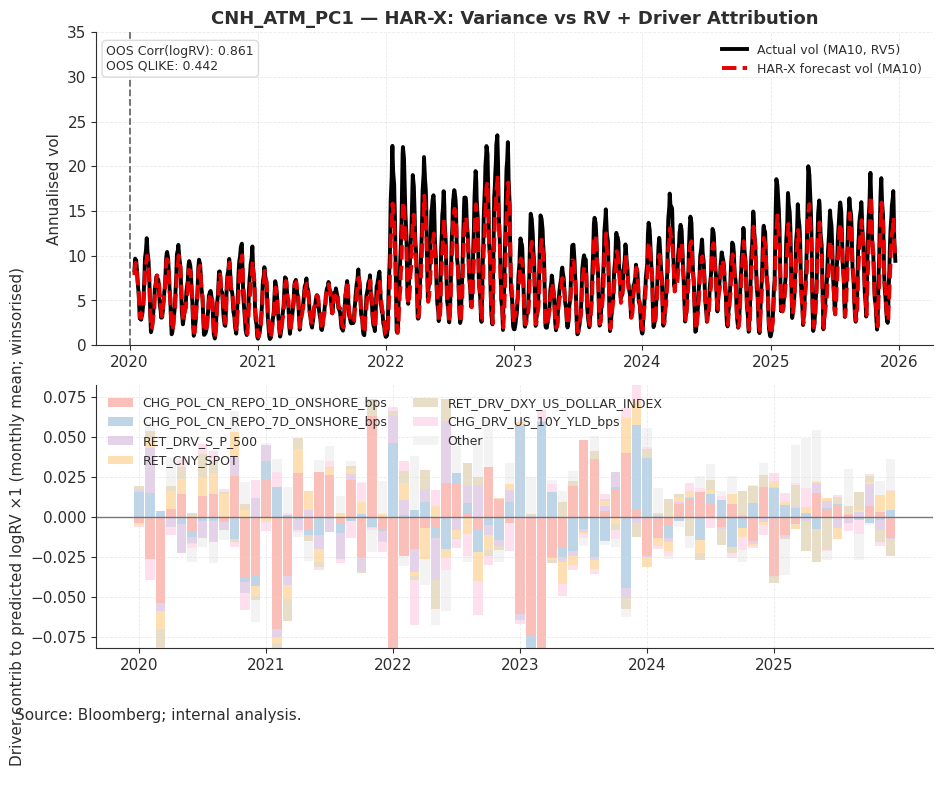

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}

=== CNH_ATM_PC2 ===


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


<Figure size 640x480 with 0 Axes>

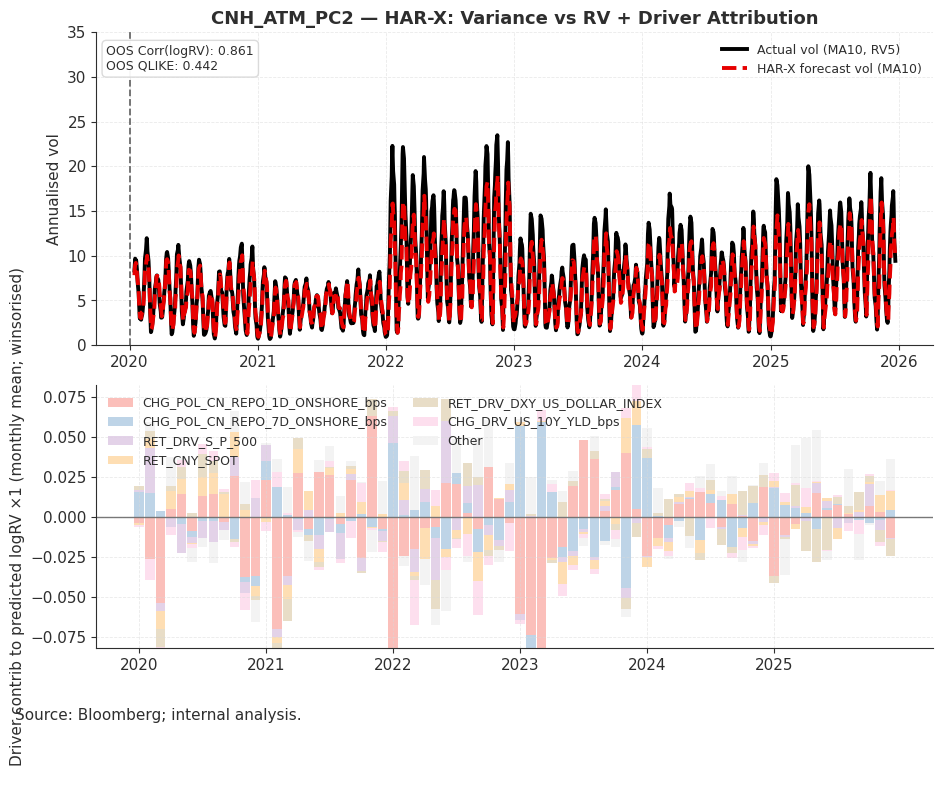

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}

=== CNH_25RR_PC1 ===


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


<Figure size 640x480 with 0 Axes>

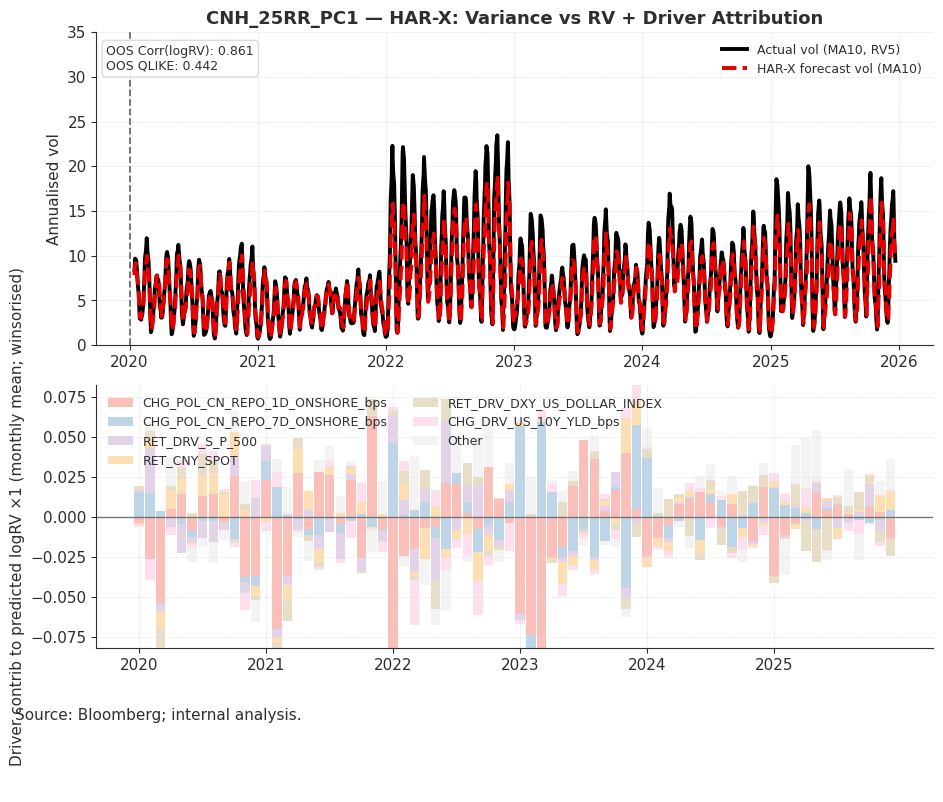

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}

=== CNH_25BF_PC1 ===


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


<Figure size 640x480 with 0 Axes>

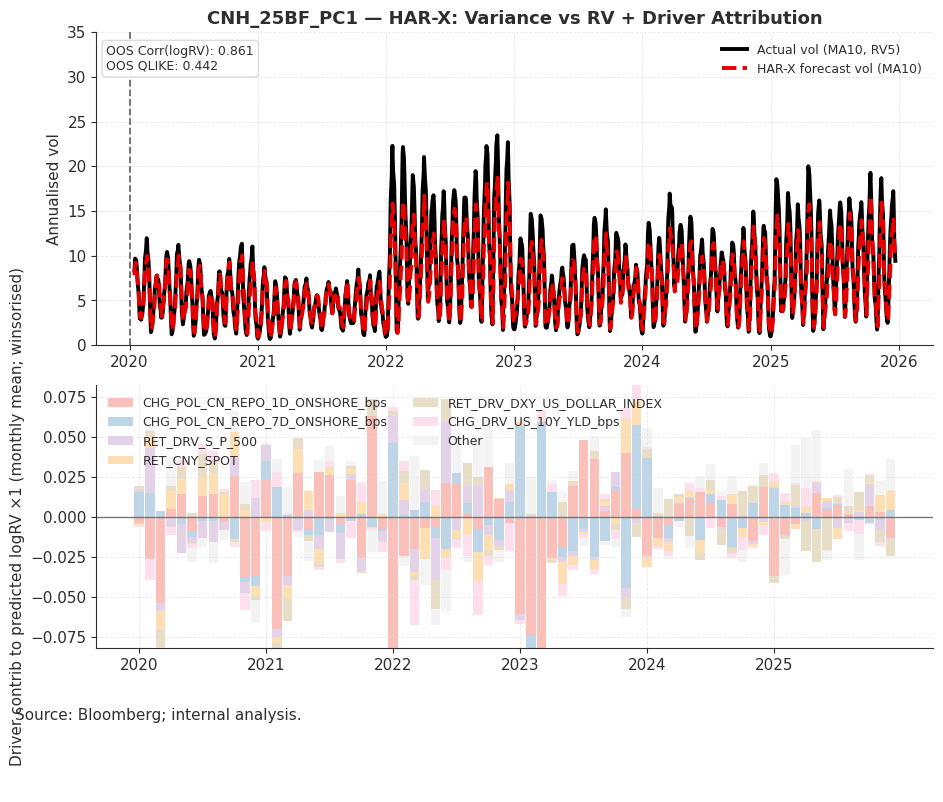

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}

=== CNH_ATM_PC1 ===


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:276: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Cm = contrib2.resample("M").mean()
/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_8062/2877325731.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


<Figure size 640x480 with 0 Axes>

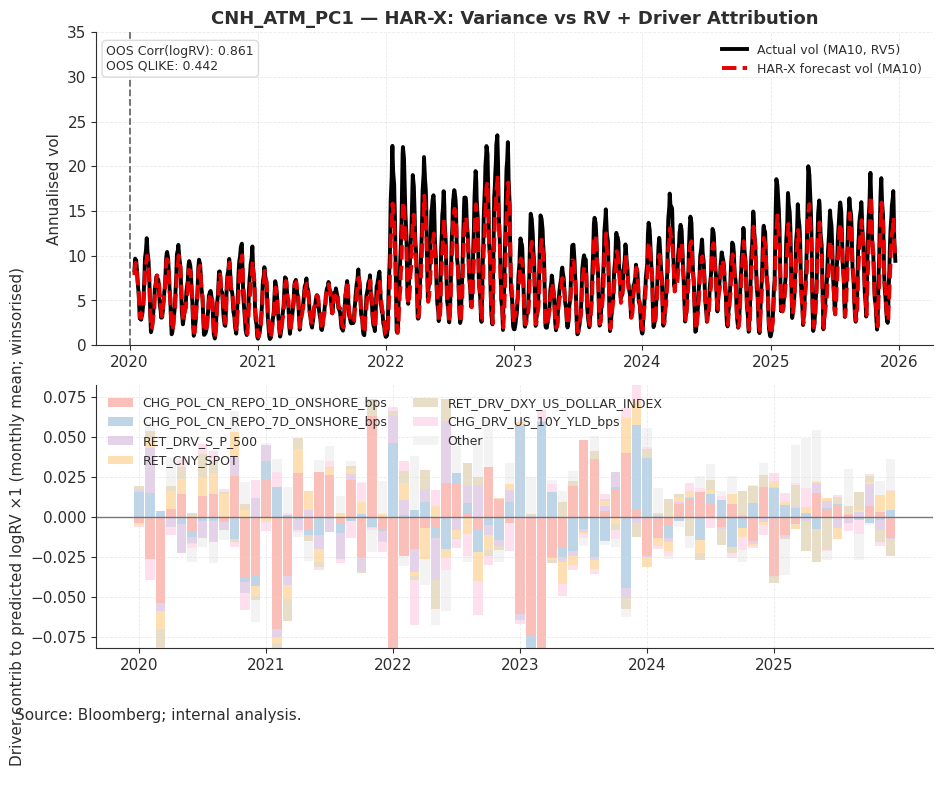

OOS metrics: {'corr_logRV_oos': 0.861282764616908, 'qlike_oos': 0.441575416353788}


<Figure size 640x480 with 0 Axes>

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def _to_cnh_factor(f: str) -> str:
    """Map CNY_* -> CNH_* if CNH version exists; otherwise keep as-is."""
    if f.startswith("CNY_"):
        cand = "CNH_" + f[len("CNY_"):]
        if cand in resid_map and cand in panel_factors.columns:
            return cand
    return f

def run_harx_panels_for_factors(
    factors: list[str] | None = None,
    window_start: str | pd.Timestamp = "2020-01-01",
    force_vol_ylim: tuple[float, float] = (0, 35),
    top_k: int = 6,
    winsor_q: tuple[float, float] = (0.01, 0.99),
    refit_every: int = 21,
    lookback: int = 1260,
    rv_window: int = 5,
    ma_vol: int = 10,
    save_dir: str | None = None,   # e.g. "HARX_PANELS"
    cnh_only: bool = True,
):
    # -----------------------------
    # choose factors (CNH-only by default)
    # -----------------------------
    if factors is None:
        base = list(resid_map.keys())
        if cnh_only:
            base = [k for k in base if str(k).startswith("CNH_")]
        factors = [k for k in base if (k in panel_factors.columns)]
    else:
        # map to CNH when possible
        factors = [_to_cnh_factor(f) for f in factors]
        if cnh_only:
            factors = [f for f in factors if str(f).startswith("CNH_")]

    # de-dupe while preserving order
    seen = set()
    factors = [f for f in factors if not (f in seen or seen.add(f))]

    if len(factors) == 0:
        raise ValueError("No eligible CNH factors found (after mapping/filtering).")

    # -----------------------------
    # build ONE macro exog block (shared)
    # -----------------------------
    exog_cols = pick_macro_exog_cols(panel_factors)
    if len(exog_cols) == 0:
        raise ValueError("pick_macro_exog_cols returned 0 columns. Check prefixes/drop_prefixes/max_nan_frac.")
    X_exog = panel_factors[exog_cols].copy()

    r_std = artifacts["r_std"].copy()

    # optional saving
    out_dir = Path(save_dir) if save_dir else None
    if out_dir:
        out_dir.mkdir(parents=True, exist_ok=True)

    out = {}

    for fac in factors:
        if fac not in panel_factors.columns:
            print(f"[skip] {fac}: not in panel_factors.columns")
            continue
        if fac not in resid_map:
            print(f"[skip] {fac}: not in resid_map")
            continue

        print(f"\n=== {fac} ===")

        # --- attribution (monthly signed stacked) ONLY ---
        res = plot_harx_attribution_panel_monthly_stacked_from_2020(
            factor_name=fac,
            r=r_std,
            X_exog=X_exog,
            oos_start=OOS_START,
            window_start=window_start,
            rv_window=rv_window,
            ma_vol=ma_vol,
            lookback=lookback,
            refit_every=refit_every,
            top_k=top_k,
            winsor_q=winsor_q,
            figsize=(10.8, 8.8),
            force_vol_ylim=force_vol_ylim,
            bottom_alpha=0.85,
            title=f"{fac} — HAR-X: Variance vs RV + Driver Attribution",
            footnote="Source: Bloomberg; internal analysis.",
        )

        if out_dir:
            plt.gcf().savefig(out_dir / f"{fac}__attrib.png", dpi=200, bbox_inches="tight")

        out[fac] = {"attrib": res}
        print("OOS metrics:", res["metrics"])

    return out


all_out = run_harx_panels_for_factors(save_dir="HARX_PANELS_2020_CNH", cnh_only=True)


sel_out = run_harx_panels_for_factors(
    factors=["CNY_ATM_PC1", "CNH_ATM_PC1", "CNY_25DRR_PC1"],
    save_dir="HARX_PANELS_SELECTED_CNH",
    cnh_only=True,
)